# Correction des rafales prévues par AROME

**Correction résiduelle de la vitesse des rafales à l’aide du Machine Learning**

Ce notebook apprend l’erreur d’AROME :

\[
	ext{correction réelle} = 	ext{rafale METAR} - 	ext{rafale AROME}
\]

puis construit la prévision corrigée :

\[
	ext{AROME corrigé} = 	ext{AROME brut} + 	ext{correction prédite}
\]

## Protocole expérimental

- **Observation de référence :** `gust_speed_ms` (METAR, en m/s).
- **Prévision brute :** `arome_gust_speed_60`, calculée à partir de `u_gust60` et `v_gust60`.
- **Cible apprise :** différence entre METAR et AROME.
- **Entraînement :** 2021–2023.
- **Validation et choix du modèle :** 2024.
- **Test final indépendant :** 2025.
- **Métrique de sélection :** MAE de la rafale corrigée sur 2024.

La correction est utile si elle diminue la MAE et le RMSE d’AROME brut, augmente le R² et rapproche le biais de zéro.

## 1. Installation et bibliothèques

In [23]:
%pip install -q xgboost pyarrow joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import json
import shutil
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATE_COLUMN = "datetime"
OBSERVED_GUST = "gust_speed_ms"
AROME_GUST = "arome_gust_speed_60"
CORRECTION_TARGET = "gust_correction_ms"

OUTPUT_DIR = Path("/content/resultats_correction_arome")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)

## 2. Chargement du dataset

In [25]:
DATASET_FILE = Path("C:\\Intern\\time-series-meteo\\data\\processed\\Dataset_features.parquet")
df = pd.read_parquet(DATASET_FILE)
print(f"Fichier : {DATASET_FILE.name}")
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
display(df.head())

Fichier : Dataset_features.parquet
Dimensions : 808,914 lignes × 29 colonnes


,datetime,icao,year,lon,lat,u10,v10,t2m,rh2m,u850,...,distance_km,elevation_m,wind_speed_ms,gust_speed_ms,wind_dir_deg,hour_sin,hour_cos,doy_sin,doy_cos,has_gust
0,2021-01-01,GMML,2021,-13.200,27.150,-0.375698,-2.860277,286.744537,0.758287,-0.529859,...,0.0,63.09,3.1,NaN,350.0,0.0,1.0,0.017202,0.999852,0
1,2021-01-01,GMMF,2021,-10.175,29.350,-1.258511,2.202223,285.141998,0.971666,0.845141,...,0.0,59.00,1.0,NaN,190.0,0.0,1.0,0.017202,0.999852,0
2,2021-01-01,GSVO,2021,-15.850,23.700,-3.117886,-5.829027,290.837311,0.849107,-1.998609,...,0.0,10.00,0.0,NaN,360.0,0.0,1.0,0.017202,0.999852,0
3,2021-01-01,GMTT,2021,-5.900,35.725,1.171177,7.928785,281.795319,0.790758,16.142016,...,0.0,18.89,3.6,NaN,170.0,0.0,1.0,0.017202,0.999852,0
4,2021-01-01,GMTA,2021,-3.850,35.175,0.593052,2.686598,281.710358,0.511949,12.251391,...,0.0,27.12,1.0,NaN,NaN,0.0,1.0,0.017202,0.999852,0


## 3. Contrôle et préparation des données

In [26]:
# Uniformiser les noms des coordonnées si nécessaire.
if "lon" not in df.columns and "longitude" in df.columns:
    df["lon"] = df["longitude"]
if "lat" not in df.columns and "latitude" in df.columns:
    df["lat"] = df["latitude"]

REQUIRED_COLUMNS = [
    DATE_COLUMN, "has_gust", OBSERVED_GUST, "lon", "lat",
    "u10", "v10", "t2m", "rh2m",
    "u850", "v850", "u950", "v950", "psurf",
    "u_gust60", "v_gust60", "tke20m", "edr20m", "pblh", "wind_dir_deg",
]

missing_columns = [column for column in REQUIRED_COLUMNS if column not in df.columns]
if missing_columns:
    raise ValueError(f"Colonnes manquantes : {missing_columns}")

df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="coerce")
df[OBSERVED_GUST] = pd.to_numeric(df[OBSERVED_GUST], errors="coerce")
df["has_gust"] = pd.to_numeric(df["has_gust"], errors="coerce")

# Intensité de la rafale brute prévue par AROME.
df[AROME_GUST] = np.hypot(df["u_gust60"], df["v_gust60"])

# La régression d'intensité concerne uniquement les vraies rafales observées.
data = df.loc[
    df[DATE_COLUMN].notna()
    & df["has_gust"].eq(1)
    & df[OBSERVED_GUST].notna()
    & np.isfinite(df[OBSERVED_GUST])
    & df[OBSERVED_GUST].gt(0)
    & df[AROME_GUST].notna()
    & np.isfinite(df[AROME_GUST])
].copy()

if data.empty:
    raise ValueError("Aucune rafale valide n'a été trouvée.")

# Cible du modèle : erreur à ajouter à AROME.
data[CORRECTION_TARGET] = data[OBSERVED_GUST] - data[AROME_GUST]
data["year"] = data[DATE_COLUMN].dt.year

print(f"Rafales conservées : {len(data):,}")
print("\nRépartition par année :")
display(data["year"].value_counts().sort_index().to_frame("Nombre"))

print("\nStatistiques en m/s :")
display(
    data[[OBSERVED_GUST, AROME_GUST, CORRECTION_TARGET]]
    .describe()
    .T
)

Rafales conservées : 24,328

Répartition par année :


,Nombre
year,
2021,5741
2022,4649
2023,3760
2024,5726
2025,4452



Statistiques en m/s :


,count,mean,std,min,25%,50%,75%,max
gust_speed_ms,24328.0,9.597507,4.012995,5.000000,6.200000,8.400000,11.800000,50.900000
arome_gust_speed_60,24328.0,9.166771,4.717263,0.020525,5.569847,8.785610,12.394625,32.039843
gust_correction_ms,24328.0,0.430736,4.746422,-17.826583,-2.548992,0.000846,3.011673,48.902776


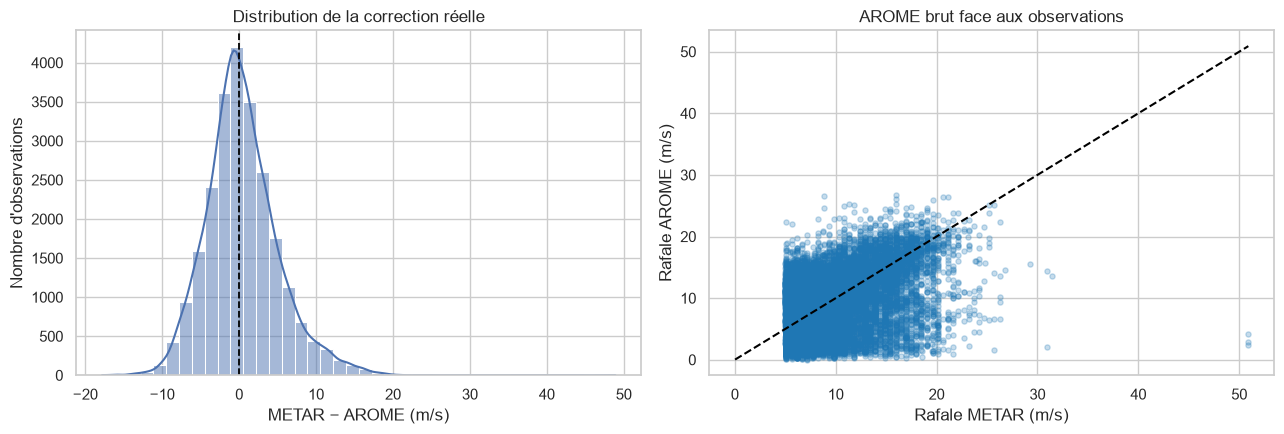

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(data=data, x=CORRECTION_TARGET, bins=40, kde=True, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.3)
axes[0].set_title("Distribution de la correction réelle")
axes[0].set_xlabel("METAR − AROME (m/s)")
axes[0].set_ylabel("Nombre d'observations")

sample_size = min(15_000, len(data))
sample = data.sample(sample_size, random_state=RANDOM_STATE)
axes[1].scatter(
    sample[OBSERVED_GUST], sample[AROME_GUST],
    alpha=0.25, s=14, color="#1f77b4",
)
low = min(sample[OBSERVED_GUST].min(), sample[AROME_GUST].min())
high = max(sample[OBSERVED_GUST].max(), sample[AROME_GUST].max())
axes[1].plot([low, high], [low, high], "--", color="black")
axes[1].set_title("AROME brut face aux observations")
axes[1].set_xlabel("Rafale METAR (m/s)")
axes[1].set_ylabel("Rafale AROME (m/s)")

plt.tight_layout()
plt.show()

## 4. Variables explicatives et découpage temporel

In [28]:
def add_derived_features(frame):
    result = frame.copy()

    result["arome_wind_speed_10m"] = np.hypot(result["u10"], result["v10"])
    result["arome_wind_speed_850"] = np.hypot(result["u850"], result["v850"])
    result["arome_wind_speed_950"] = np.hypot(result["u950"], result["v950"])
    result[AROME_GUST] = np.hypot(result["u_gust60"], result["v_gust60"])

    result["shear_850_10"] = np.hypot(
        result["u850"] - result["u10"],
        result["v850"] - result["v10"],
    )
    result["shear_950_10"] = np.hypot(
        result["u950"] - result["u10"],
        result["v950"] - result["v10"],
    )

    date = result[DATE_COLUMN]
    result["hour_sin"] = np.sin(2 * np.pi * date.dt.hour / 24)
    result["hour_cos"] = np.cos(2 * np.pi * date.dt.hour / 24)
    result["month_sin"] = np.sin(2 * np.pi * date.dt.month / 12)
    result["month_cos"] = np.cos(2 * np.pi * date.dt.month / 12)
    return result


data = add_derived_features(data)

FEATURES = [
    "lon", "lat",
    "u10", "v10", "t2m", "rh2m",
    "u850", "v850", "u950", "v950", "psurf",
    "u_gust60", "v_gust60", "tke20m", "edr20m", "pblh",
    "arome_wind_speed_10m",
    "arome_wind_speed_850",
    "arome_wind_speed_950",
    AROME_GUST,
    "shear_850_10", "shear_950_10",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
]

# Découpage strictement chronologique.
train_df = data[data["year"].between(2021, 2023)].copy()
validation_df = data[data["year"].eq(2024)].copy()
test_df = data[data["year"].eq(2025)].copy()

split_table = pd.DataFrame(
    {
        "Période": ["2021–2023", "2024", "2025"],
        "Rôle": ["Entraînement", "Validation", "Test final"],
        "Nombre": [len(train_df), len(validation_df), len(test_df)],
    }
)
display(split_table)

if min(len(train_df), len(validation_df), len(test_df)) == 0:
    raise ValueError("Une période du découpage temporel est vide.")

X_train = train_df[FEATURES]
y_train_correction = train_df[CORRECTION_TARGET]

X_validation = validation_df[FEATURES]
y_validation_observed = validation_df[OBSERVED_GUST].to_numpy()
arome_validation = validation_df[AROME_GUST].to_numpy()

X_test = test_df[FEATURES]
y_test_observed = test_df[OBSERVED_GUST].to_numpy()
arome_test = test_df[AROME_GUST].to_numpy()

print(f"Nombre de variables : {len(FEATURES)}")
print(f"Valeurs manquantes dans X_train : {int(X_train.isna().sum().sum()):,}")

,Période,Rôle,Nombre
0,2021–2023,Entraînement,14150
1,2024,Validation,5726
2,2025,Test final,4452


Nombre de variables : 26
Valeurs manquantes dans X_train : 0


## 5. Modèles de correction

Les trois modèles apprennent la **correction**, et non l’intensité complète. La même reconstruction est ensuite appliquée à chaque modèle :

`rafale corrigée = rafale AROME + correction prédite`

In [29]:
models = {
    "Régression linéaire": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=2,
                    max_features="sqrt",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "XGBoost": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    n_estimators=600,
                    learning_rate=0.04,
                    max_depth=6,
                    min_child_weight=3,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    reg_alpha=0.05,
                    reg_lambda=1.0,
                    tree_method="hist",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

print("Modèles comparés :", list(models))

Modèles comparés : ['Régression linéaire', 'Random Forest', 'XGBoost']


In [30]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        # Biais > 0 : surestimation ; biais < 0 : sous-estimation.
        "Biais": float(np.mean(y_pred - y_true)),
    }


def add_improvements(metrics, raw_metrics):
    result = dict(metrics)
    result["Gain_MAE_%"] = float(
        100 * (raw_metrics["MAE"] - metrics["MAE"]) / raw_metrics["MAE"]
    )
    result["Gain_RMSE_%"] = float(
        100 * (raw_metrics["RMSE"] - metrics["RMSE"]) / raw_metrics["RMSE"]
    )
    return result

## 6. Comparaison sur la validation 2024

In [31]:
raw_validation_metrics = regression_metrics(
    y_validation_observed,
    arome_validation,
)

validation_rows = [
    {
        "Modèle": "AROME brut",
        **raw_validation_metrics,
        "Gain_MAE_%": 0.0,
        "Gain_RMSE_%": 0.0,
        "Temps_s": 0.0,
    }
]
fitted_models = {}

for model_name, estimator in models.items():
    print(f"Entraînement : {model_name}")
    start = time.perf_counter()
    estimator.fit(X_train, y_train_correction)
    duration = time.perf_counter() - start

    predicted_correction = estimator.predict(X_validation)
    corrected_validation = np.maximum(
        arome_validation + predicted_correction,
        0.0,
    )

    metrics = regression_metrics(
        y_validation_observed,
        corrected_validation,
    )
    metrics = add_improvements(metrics, raw_validation_metrics)
    validation_rows.append(
        {"Modèle": model_name, **metrics, "Temps_s": float(duration)}
    )
    fitted_models[model_name] = estimator

comparison_validation = pd.DataFrame(validation_rows).loc[
    :,
    [
        "Modèle", "MAE", "RMSE", "R2", "Biais",
        "Gain_MAE_%", "Gain_RMSE_%", "Temps_s",
    ],
]

print("Comparaison sur la validation 2024 :")
display(
    comparison_validation.style.format(
        {
            "MAE": "{:.3f}", "RMSE": "{:.3f}", "R2": "{:.3f}",
            "Biais": "{:.3f}", "Gain_MAE_%": "{:+.1f}%",
            "Gain_RMSE_%": "{:+.1f}%", "Temps_s": "{:.1f}",
        }
    ).highlight_min(subset=["MAE"], color="#c6efce")
)

Entraînement : Régression linéaire
Entraînement : Random Forest
Entraînement : XGBoost
Comparaison sur la validation 2024 :


,Modèle,MAE,RMSE,R2,Biais,Gain_MAE_%,Gain_RMSE_%,Temps_s
0,AROME brut,3.532,4.840,-0.220,-1.390,+0.0%,+0.0%,0.0
1,Régression linéaire,2.493,3.224,0.459,0.008,+29.4%,+33.4%,0.1
2,Random Forest,2.276,3.015,0.526,0.075,+35.6%,+37.7%,4.7
3,XGBoost,2.151,2.857,0.575,0.126,+39.1%,+41.0%,3.0


In [32]:
# Le modèle est sélectionné uniquement parmi les modèles de correction.
corrected_validation_results = comparison_validation[
    comparison_validation["Modèle"].ne("AROME brut")
].sort_values(["MAE", "RMSE"], ascending=True)

best_model_name = str(corrected_validation_results.iloc[0]["Modèle"])
best_validation_mae = float(corrected_validation_results.iloc[0]["MAE"])

print(f"Modèle de correction sélectionné : {best_model_name}")

if best_validation_mae < raw_validation_metrics["MAE"]:
    print("La correction améliore AROME brut sur 2024.")
else:
    print(
        "Attention : aucun modèle ne réduit la MAE d'AROME sur 2024. "
        "La correction n'est donc pas validée."
    )

Modèle de correction sélectionné : XGBoost
La correction améliore AROME brut sur 2024.


## 7. Réentraînement et test final 2025

Le modèle choisi sur 2024 est réentraîné sur 2021–2024. Les données 2025 sont ensuite utilisées **une seule fois** pour l’évaluation finale.

In [33]:
train_validation_df = (
    pd.concat([train_df, validation_df], axis=0)
    .sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)

X_train_validation = train_validation_df[FEATURES]
y_train_validation_correction = train_validation_df[CORRECTION_TARGET]

final_model = clone(models[best_model_name])
start = time.perf_counter()
final_model.fit(X_train_validation, y_train_validation_correction)
final_training_seconds = time.perf_counter() - start

predicted_test_correction = final_model.predict(X_test)
corrected_test = np.maximum(
    arome_test + predicted_test_correction,
    0.0,
)

raw_test_metrics = regression_metrics(y_test_observed, arome_test)
corrected_test_metrics = regression_metrics(y_test_observed, corrected_test)
corrected_test_metrics = add_improvements(
    corrected_test_metrics,
    raw_test_metrics,
)

comparison_test = pd.DataFrame(
    [
        {
            "Prévision": "AROME brut",
            **raw_test_metrics,
            "Gain_MAE_%": 0.0,
            "Gain_RMSE_%": 0.0,
        },
        {
            "Prévision": f"AROME corrigé — {best_model_name}",
            **corrected_test_metrics,
        },
    ]
)

print("RÉSULTATS DU TEST FINAL 2025")
display(
    comparison_test.style.format(
        {
            "MAE": "{:.3f}", "RMSE": "{:.3f}", "R2": "{:.3f}",
            "Biais": "{:.3f}", "Gain_MAE_%": "{:+.1f}%",
            "Gain_RMSE_%": "{:+.1f}%",
        }
    ).highlight_min(subset=["MAE", "RMSE"], color="#c6efce")
)

if corrected_test_metrics["MAE"] < raw_test_metrics["MAE"]:
    print(
        f"Conclusion : la correction réduit la MAE de "
        f"{corrected_test_metrics['Gain_MAE_%']:.1f}% sur 2025."
    )
else:
    print("Conclusion : la correction n'améliore pas la MAE sur 2025.")

RÉSULTATS DU TEST FINAL 2025


,Prévision,MAE,RMSE,R2,Biais,Gain_MAE_%,Gain_RMSE_%
0,AROME brut,3.267,4.397,-0.363,-0.897,+0.0%,+0.0%
1,AROME corrigé — XGBoost,2.007,2.759,0.463,0.536,+38.6%,+37.3%


Conclusion : la correction réduit la MAE de 38.6% sur 2025.


## 8. Analyse graphique sur 2025

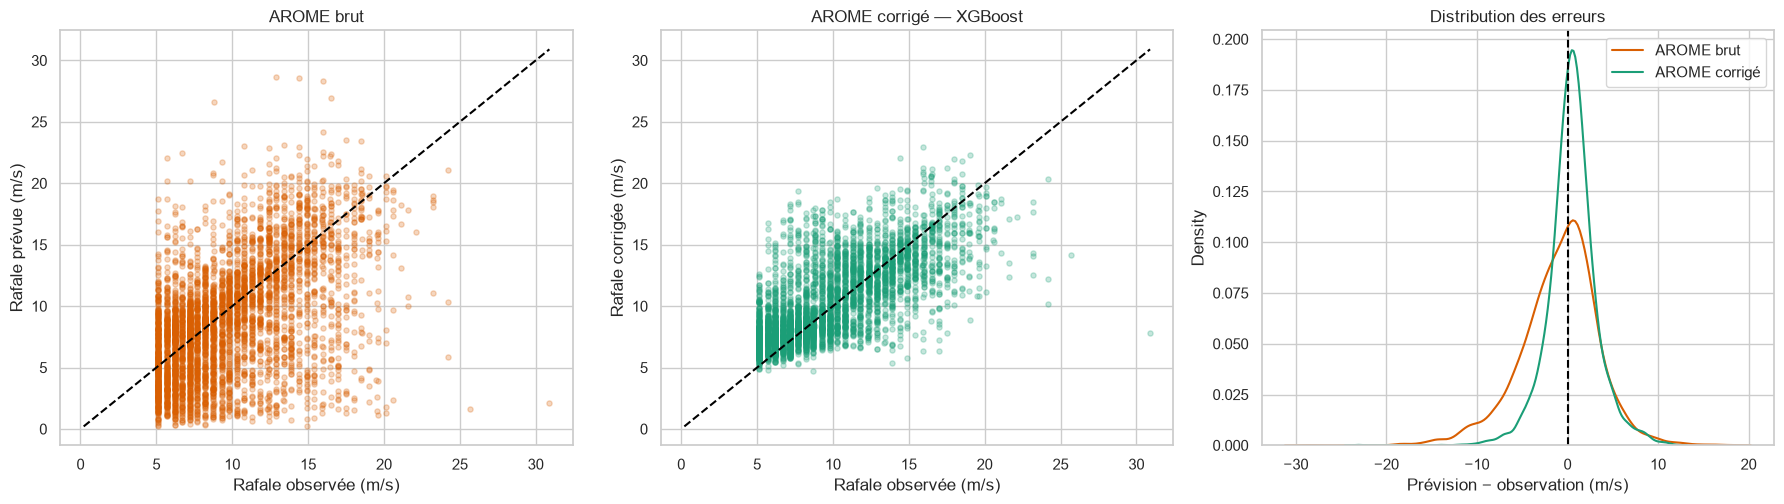

In [34]:
plot_size = min(15_000, len(test_df))
plot_indices = np.random.default_rng(RANDOM_STATE).choice(
    len(test_df), size=plot_size, replace=False
)

observed_plot = y_test_observed[plot_indices]
raw_plot = arome_test[plot_indices]
corrected_plot = corrected_test[plot_indices]

low = min(observed_plot.min(), raw_plot.min(), corrected_plot.min())
high = max(observed_plot.max(), raw_plot.max(), corrected_plot.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

axes[0].scatter(observed_plot, raw_plot, alpha=0.25, s=14, color="#d95f02")
axes[0].plot([low, high], [low, high], "--", color="black")
axes[0].set_title("AROME brut")
axes[0].set_xlabel("Rafale observée (m/s)")
axes[0].set_ylabel("Rafale prévue (m/s)")

axes[1].scatter(
    observed_plot, corrected_plot, alpha=0.25, s=14, color="#1b9e77"
)
axes[1].plot([low, high], [low, high], "--", color="black")
axes[1].set_title(f"AROME corrigé — {best_model_name}")
axes[1].set_xlabel("Rafale observée (m/s)")
axes[1].set_ylabel("Rafale corrigée (m/s)")

raw_errors = arome_test - y_test_observed
corrected_errors = corrected_test - y_test_observed
sns.kdeplot(raw_errors, label="AROME brut", ax=axes[2], color="#d95f02")
sns.kdeplot(
    corrected_errors, label="AROME corrigé", ax=axes[2], color="#1b9e77"
)
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("Distribution des erreurs")
axes[2].set_xlabel("Prévision − observation (m/s)")
axes[2].legend()

plt.tight_layout()
figure_path = OUTPUT_DIR / "comparaison_arome_2025.png"
plt.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

,Variable,Importance
0,arome_gust_speed_60,0.382100
1,arome_wind_speed_10m,0.110012
2,lon,0.103976
3,lat,0.051248
4,hour_cos,0.039526
5,v10,0.028330
6,hour_sin,0.024128
7,month_sin,0.022945
8,psurf,0.021595
9,v_gust60,0.021395


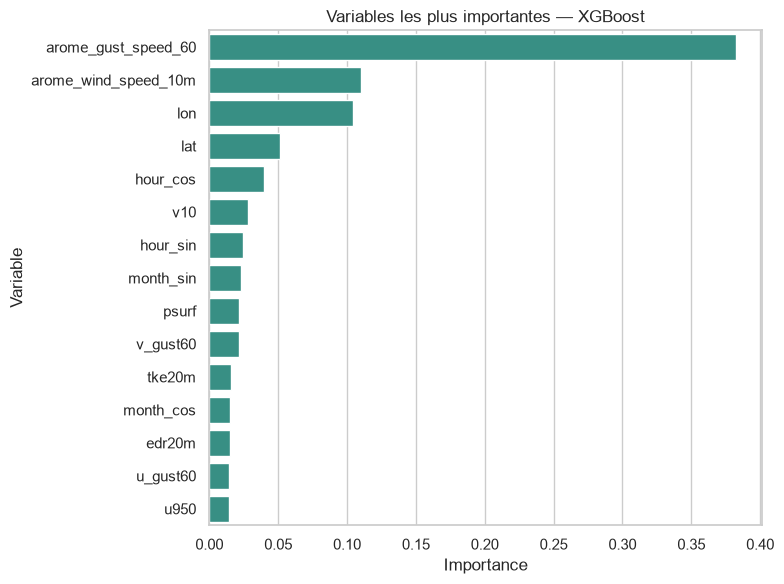

In [35]:
# Importance des variables si le modèle sélectionné la fournit.
internal_model = final_model.named_steps["model"]

if hasattr(internal_model, "feature_importances_"):
    feature_importance = (
        pd.DataFrame(
            {
                "Variable": FEATURES,
                "Importance": internal_model.feature_importances_,
            }
        )
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    display(feature_importance.head(15))

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=feature_importance.head(15),
        x="Importance",
        y="Variable",
        color="#2a9d8f",
    )
    plt.title(f"Variables les plus importantes — {best_model_name}")
    plt.tight_layout()
    importance_figure_path = OUTPUT_DIR / "importance_variables.png"
    plt.savefig(importance_figure_path, dpi=180, bbox_inches="tight")
    plt.show()
else:
    feature_importance = None
    importance_figure_path = None
    print("Ce modèle ne fournit pas d'importance d'arbre.")

## 9. Sauvegarde du modèle et des résultats

In [36]:
model_path = OUTPUT_DIR / "modele_correction_arome.joblib"
metrics_path = OUTPUT_DIR / "resultats_correction_arome.json"
validation_path = OUTPUT_DIR / "comparaison_validation_2024.csv"
test_path = OUTPUT_DIR / "comparaison_test_2025.csv"
predictions_path = OUTPUT_DIR / "predictions_corrigees_2025.csv"

# Le fichier contient le pipeline et les informations nécessaires à son usage.
model_artifact = {
    "model": final_model,
    "features": FEATURES,
    "observed_target": OBSERVED_GUST,
    "arome_baseline": AROME_GUST,
    "correction_target": CORRECTION_TARGET,
    "formula": "gust_corrected = arome_gust + predicted_correction",
    "selected_model": best_model_name,
}
joblib.dump(model_artifact, model_path)

comparison_validation.to_csv(validation_path, index=False)
comparison_test.to_csv(test_path, index=False)

identification_columns = [
    column for column in [DATE_COLUMN, "station_id", "wmo"]
    if column in test_df.columns
]
predictions_2025 = test_df[identification_columns].reset_index(drop=True).copy()
predictions_2025["gust_observed_ms"] = y_test_observed
predictions_2025["arome_raw_ms"] = arome_test
predictions_2025["predicted_correction_ms"] = predicted_test_correction
predictions_2025["arome_corrected_ms"] = corrected_test
predictions_2025["raw_error_ms"] = arome_test - y_test_observed
predictions_2025["corrected_error_ms"] = corrected_test - y_test_observed
predictions_2025.to_csv(predictions_path, index=False)

if feature_importance is not None:
    feature_importance.to_csv(
        OUTPUT_DIR / "importance_variables.csv",
        index=False,
    )

complete_results = {
    "method": "correction résiduelle d'AROME",
    "observed_target": OBSERVED_GUST,
    "arome_baseline": AROME_GUST,
    "correction_target": CORRECTION_TARGET,
    "unit": "m/s",
    "split": {
        "training": "2021-2023",
        "validation": "2024",
        "test": "2025",
    },
    "selection_metric": "MAE de la prévision corrigée sur 2024",
    "selected_model": best_model_name,
    "features": FEATURES,
    "final_training_seconds": float(final_training_seconds),
    "validation_comparison": comparison_validation.to_dict(orient="records"),
    "test_2025": {
        "arome_raw": raw_test_metrics,
        "arome_corrected": corrected_test_metrics,
    },
}

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(complete_results, file, indent=2, ensure_ascii=False)

archive_path = Path(
    shutil.make_archive(
        "/content/resultats_correction_arome",
        "zip",
        root_dir=OUTPUT_DIR,
    )
)

print("Fichiers enregistrés :")
for path in [
    model_path, metrics_path, validation_path, test_path,
    predictions_path, figure_path,
]:
    print("-", path)
print("\nArchive prête :", archive_path)

Fichiers enregistrés :
- \content\resultats_correction_arome\modele_correction_arome.joblib
- \content\resultats_correction_arome\resultats_correction_arome.json
- \content\resultats_correction_arome\comparaison_validation_2024.csv
- \content\resultats_correction_arome\comparaison_test_2025.csv
- \content\resultats_correction_arome\predictions_corrigees_2025.csv
- \content\resultats_correction_arome\comparaison_arome_2025.png

Archive prête : c:\content\resultats_correction_arome.zip
